In [1]:
using Pkg
Pkg.activate("..")   # activate project environment

using Plots
using LaTeXStrings
using DataFrames

using Revise # automatically sync src updates ----> suuuuuper important for development
using SkyrmionTunneling
const ST = SkyrmionTunneling # alias for easier referencing

  Activating project at `~/Documents/GitHub/skyrmion-tunnelling`
[ Info: Precompiling SkyrmionTunneling [51d433a5-d9a2-4638-a6de-06b0503db32e] (cache misses: include_dependency fsize change (2), wrong source (2))


SkyrmionTunneling

In [2]:
ST.test_energy_functional()

E_ferromagnetic = 0 -------> OK

H is Sz invariant -------> OK

H vector and H stereographic consistent -------> OK


# Dipolar probe

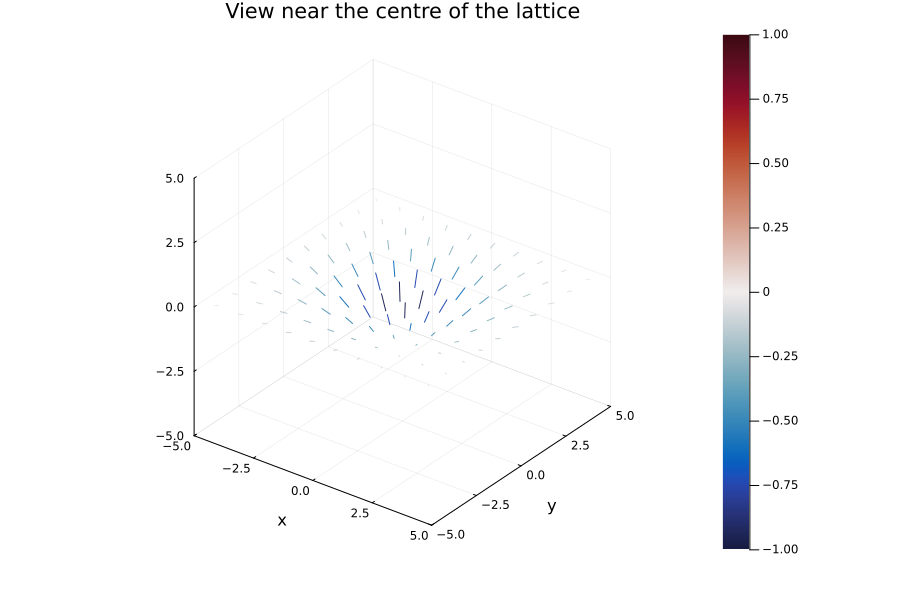

In [17]:
lattice = SquareLattice(40,40)
B = ST.dipole_B_field(lattice, B0 = -1.0, h = 5.0, B_inf=0.0)
ST.three_dee_quiver(B,lattice)

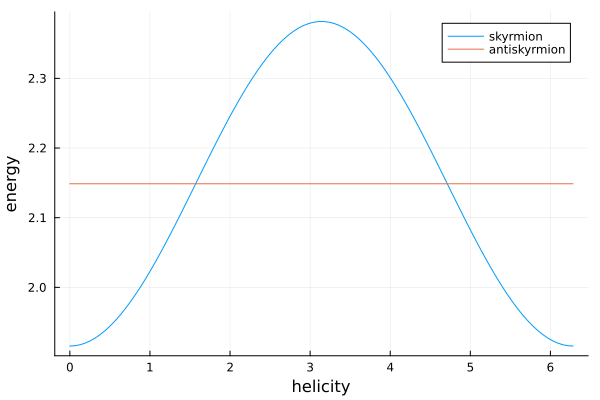

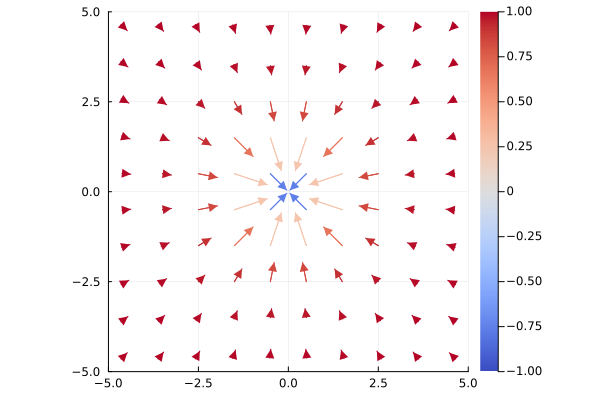

In [19]:
lattice = SquareLattice(40,40)
J1 = 1.0;	J2 = -0.3;	J3 = -0.2
K = 0.02

B = ST.dipole_B_field(lattice, B0 = 0.22, h = 5.0, B_inf=0.2)

params = HamiltonianParameters(J1,J2,J3,K,B)
boundary = PeriodicBoundary()
system = System(params,lattice,boundary)

helicity_list = LinRange(0,2pi,100)
Sk_energy_list = [ST.H(ST.skyrmion_ansatz(system, radius=2.0, relax_length=2.0, topological_charge=1.0, helicity=helicity),system) for helicity in helicity_list]
aSk_energy_list = [ST.H(ST.skyrmion_ansatz(system, radius=2.0, relax_length=2.0, topological_charge=-1.0, helicity=helicity),system) for helicity in helicity_list]
P = plot()
plot!(P,helicity_list, Sk_energy_list,label="skyrmion", xlabel="helicity", ylabel="energy")
plot!(P,helicity_list, aSk_energy_list,label="antiskyrmion", xlabel="helicity", ylabel="energy")
display(P)

n = ST.skyrmion_ansatz(system, radius=2.0, relax_length=2.0, topological_charge=1.0, helicity=pi) 
ST.in_plane_quiver(n,lattice)

Launching LLG relaxation for
SquareLattice(40, 40)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.3	J3 = -0.2
K = 0.02
Bz_avg = 0.2	B_uniform = false



Progress:  94%|██████████████████████████████████████▋  |  ETA: 0:00:03

could not find an improving step; stopped early


Progress: 100%|█████████████████████████████████████████| Time: 0:00:53


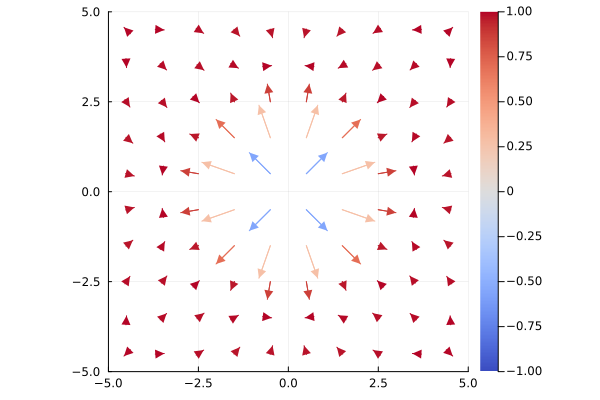

LambdaCoordinate{Matrix{ComplexF64}}(ComplexF64[0.0023521602772005 + 0.002356372551538935im 0.005500485017895541 + 0.0008596486457312065im … -0.005499214167362925 + 0.0008613364636154953im -0.002348449512279205 + 0.0023570715918852393im; 0.0008566805659295505 + 0.00550329107197915im 0.0019262650481548375 + 0.0019304276951244844im … -0.0019258973234723403 + 0.0019344155508269616im -0.0008552287646441192 + 0.005504952739588743im; … ; 0.0008615405098841568 - 0.00549958991190646im 0.0019378811600447364 - 0.0019293738046574289im … -0.0019375218991376088 - 0.001933347238176156im -0.000860111597366081 - 0.005501245242580132im; 0.0023541722947629843 - 0.0023455626862265207im 0.00550532463791548 - 0.0008554630588039273im … -0.005504057567327741 - 0.0008571127094718858im -0.0023504714180127857 - 0.002346245499557591im])

In [20]:
n_Sk = ST.skyrmion(system, annealing=true, LLG_relax=true, show_result=false, N_steps=10000)
ST.in_plane_quiver(n_Sk,lattice)
coord = LambdaCoordinate(ST.w_project(n_Sk))

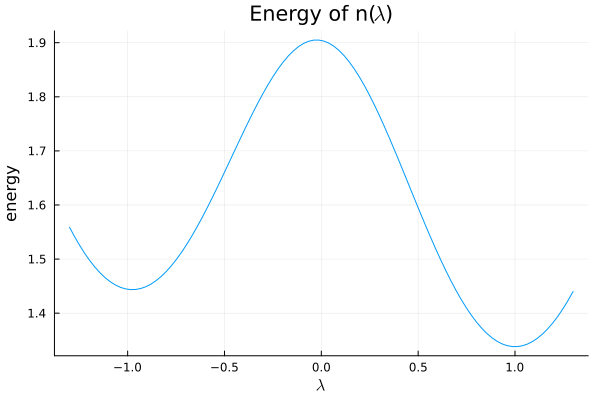

Imaginary part = 2.9228247557576e-5
WARNING ----> imaginary part is nonzero !!!!! ---------> It gets neglected via a real projection


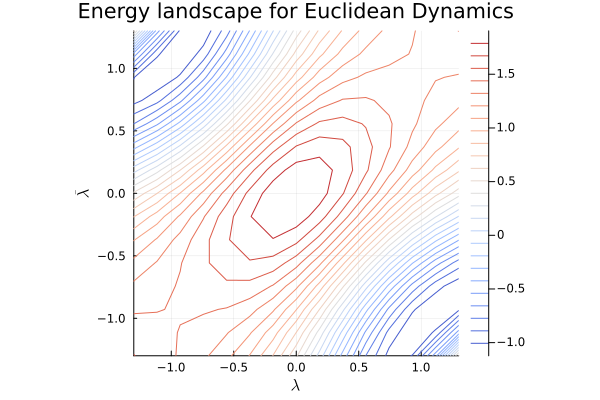

Imaginary part = 0.0007132093765868617
WARNING ----> imaginary part is nonzero !!!!! ---------> It gets neglected via a real projection


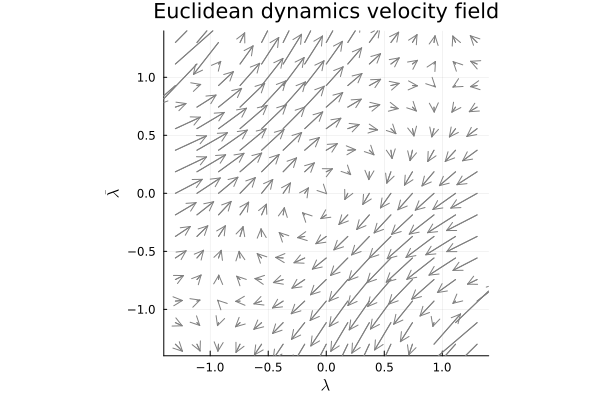

In [22]:
ST.describe_collective_coordinate(system, coord, xmin=-1.3, xmax=1.3)

The saddle point is at -0.9756319530310716 + 3.206557310583872e-8im
The instantonic trajectory passes through the point 
 x = -0.9726490535208762 + 6.95774315439332e-8im
 y = -0.9257207695449158 + 3.1841246854789366e-8im
sanity check : |H_inst-H0| = 9.777068047812005e-12
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:09


-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


imaginary = 4.783971130756057e-6


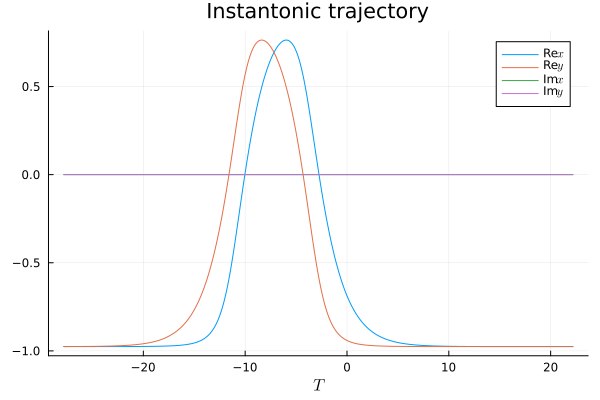

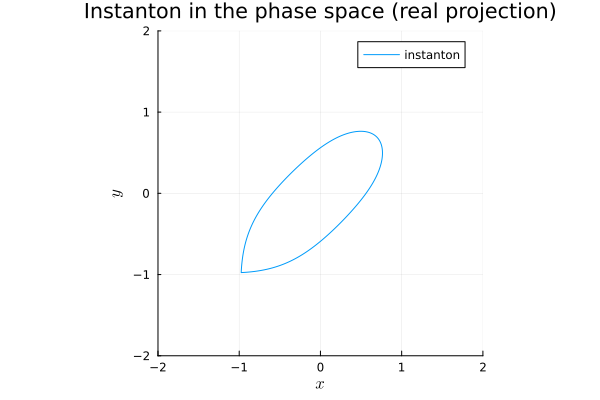


Total action = 11.041317905587121 - 3.323850088896474e-9im


(11.041317905587121 - 3.323850088896474e-9im, ComplexF64[-0.975616170154541 + 3.2263780440012175e-8im -0.9756159852744601 + 3.226623917823316e-8im … -0.9756272565830777 + 3.206675167687777e-8im -0.9756273025104938 + 3.20667490892903e-8im; -0.9753444806784634 - 3.169827282008673e-8im -0.9753407619051605 - 3.169336524108701e-8im … -0.9756366352302303 - 3.208756617949056e-8im -0.9756367234717338 - 3.2087668428915616e-8im])

In [23]:
S_inst, sol = ST.instanton(system,coord, x_init = -1.0, direction_guess=[0.00, 0.05], T_backward=10.0, T_forward=40.0, dt=0.025)

In [24]:
ST.test_energy_conservation(sol, system, coord)

energy_diff = 2.428350853775121e-10
Energy conserved


2.428350853775121e-10

0.7637170019867009


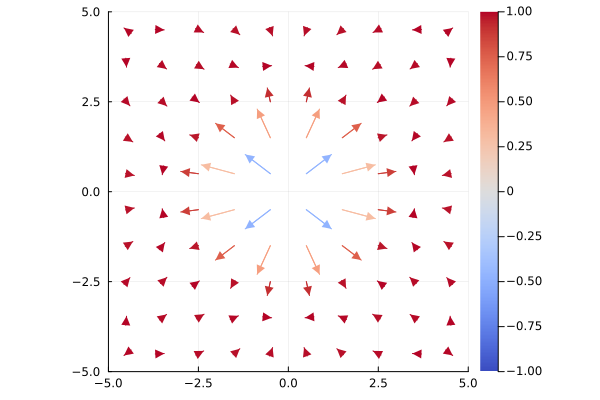

In [25]:
lambda0 = maximum(real.(sol))
println(lambda0)
ST.in_plane_quiver(ST.n(lambda0,lattice,coord),lattice)

# Field in the $y$ direction

A skyrmion is obtained from an antiskyrmion by reflecting each spin according to 
$$
(S_x, S_y, S_z) \to (S_x, -S_y, S_z)
$$
For each individual spin, this reflection be continuously interpolated by some rotation (around $x$ or a rotation around $z$, for example).

NB This does not violate the topological protection as it is impossible to match all the required rotations in a such a way that rotations for neighbouring spins are always close. In the continuum, the intermediate configurations between a skyrmion and the antiskyrmion are necessarily singular and therefore do not define a valid interpolation.

Launching LLG relaxation for
SquareLattice(40, 40)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.3	J3 = -0.2
K = 0.02
Bz_avg = 0.2	B_uniform = true



Progress: 100%|█████████████████████████████████████████| Time: 0:00:52


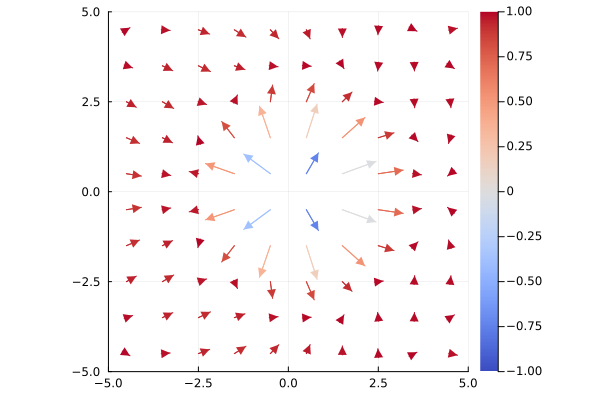

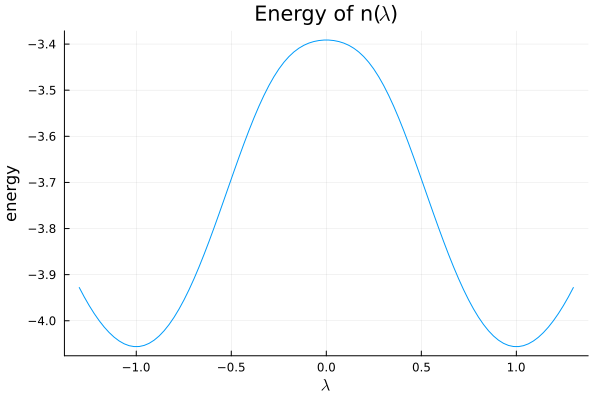

Imaginary part = 3.103126886309579e-14


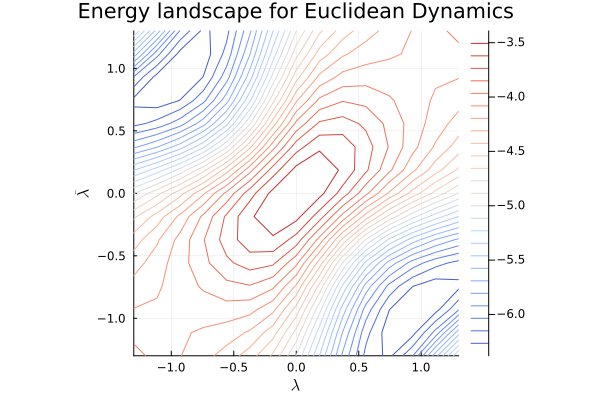

Imaginary part = 6.135260584495285e-13


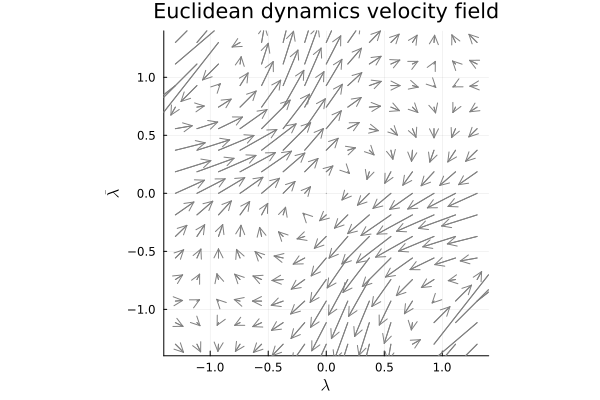

In [33]:
lattice = SquareLattice(40,40)
J1 = 1.0;	J2 = -0.3;	J3 = -0.2
K = 0.02

B = zeros(3, lattice.nx, lattice.ny)
B[3,:,:] .= 0.20
B[1,:,:] .= 0.04

params = HamiltonianParameters(J1,J2,J3,K,B)
boundary = PeriodicBoundary()
system = System(params,lattice,boundary)

"""
helicity_list = LinRange(0,2pi,100)
Sk_energy_list = [ST.H(ST.skyrmion_ansatz(system, radius=2.0, relax_length=2.0, topological_charge=1.0, helicity=helicity),system) for helicity in helicity_list]
aSk_energy_list = [ST.H(ST.skyrmion_ansatz(system, radius=2.0, relax_length=2.0, topological_charge=-1.0, helicity=helicity),system) for helicity in helicity_list]
P = plot()
plot!(P,helicity_list, Sk_energy_list,label="skyrmion", xlabel="helicity", ylabel="energy")
plot!(P,helicity_list, aSk_energy_list,label="antiskyrmion", xlabel="helicity", ylabel="energy")
display(P)
"""

n_Sk = ST.skyrmion(system, annealing=false, LLG_relax=true, show_result=false, N_steps=10000)
ST.in_plane_quiver(n_Sk,lattice)
coord = LambdaCoordinate(ST.w_project(n_Sk))
ST.describe_collective_coordinate(system,coord, xmin=-1.3, xmax=1.3)

The saddle point is at -1.0000000455629798 + 9.678964366336828e-18im
The instantonic trajectory passes through the point 
 x = -1.0021606599471038 + 7.255021252284733e-16im
 y = -0.9500466213333157 + 3.135609936841266e-17im
sanity check : |H_inst-H0| = 3.1832314562104898e-12
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


imaginary = 3.0550266285747726e-13


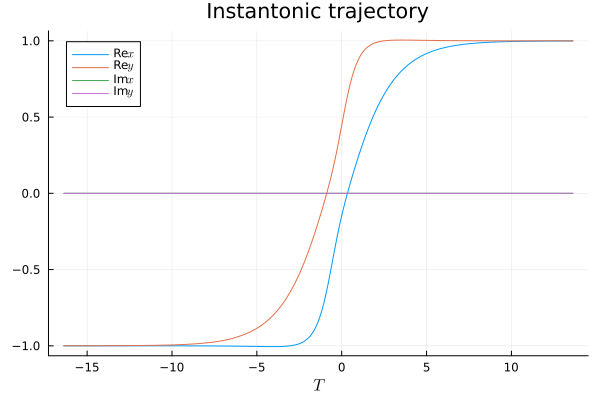

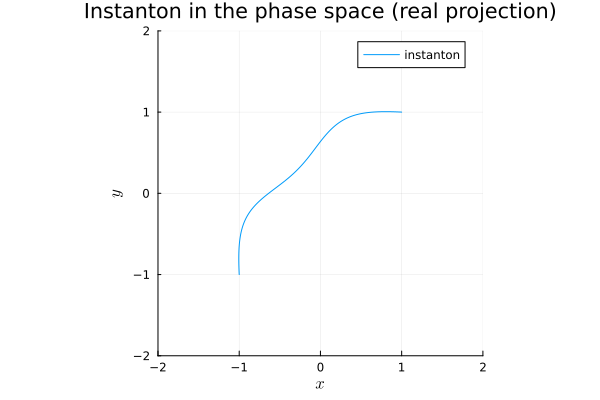


Total action = 7.709349107521611 + 1.5042492876739896e-12im


(7.709349107521611 + 1.5042492876739896e-12im, ComplexF64[-1.0000063957773901 + 3.0550266285747726e-13im -1.0000065782610046 + 2.964568508739424e-13im … 0.9995053819156959 + 8.108124513514888e-16im 0.9995200867096316 + 8.403007957153877e-16im; -0.9998761314678254 - 1.4462777743633292e-14im -0.9998723395996473 - 1.4031249116185885e-14im … 1.000002820880052 - 1.7822199878824466e-14im 1.0000014734105533 - 1.836599776515721e-14im])

In [36]:
S_inst, sol = ST.instanton(system,coord, x_init = -1.0, direction_guess=[0.00, 0.05], T_backward=10.0, T_forward=20.0, dt=0.05)

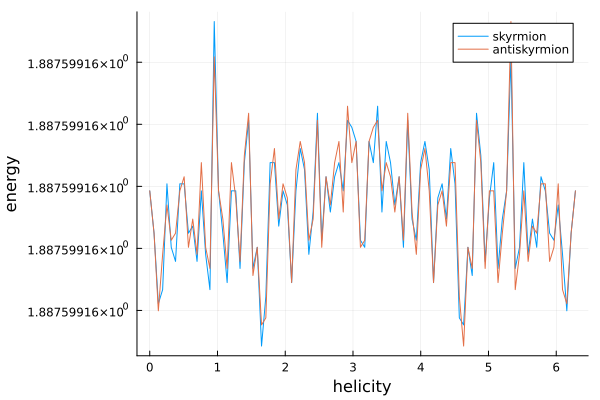

In [37]:
helicity_list = LinRange(0,2pi,100)
Sk_energy_list = [ST.H(ST.skyrmion_ansatz(system, radius=2.0, relax_length=2.0, topological_charge=1.0, helicity=helicity),system) for helicity in helicity_list]
aSk_energy_list = [ST.H(ST.skyrmion_ansatz(system, radius=2.0, relax_length=2.0, topological_charge=-1.0, helicity=helicity),system) for helicity in helicity_list]
P = plot()
plot!(P,helicity_list, Sk_energy_list,label="skyrmion", xlabel="helicity", ylabel="energy")
plot!(P,helicity_list, aSk_energy_list,label="antiskyrmion", xlabel="helicity", ylabel="energy")
display(P)

The saddle point is at -1.0000022121817 - 3.743589451950355e-5im
The instantonic trajectory passes through the point 
 x = -1.0021643749253237

Progress:   1%|▍                                        |  ETA: 0:00:10

 + 3.398882683187389e-5im
 y = -0.950048888047119 - 3.708493506544644e-5im
sanity check : |H_inst-H0| = 1.86730447914611e-11
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:09
Progress:   4%|█▉                                       |  ETA: 0:00:02

-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


imaginary = 0.03419513714878117


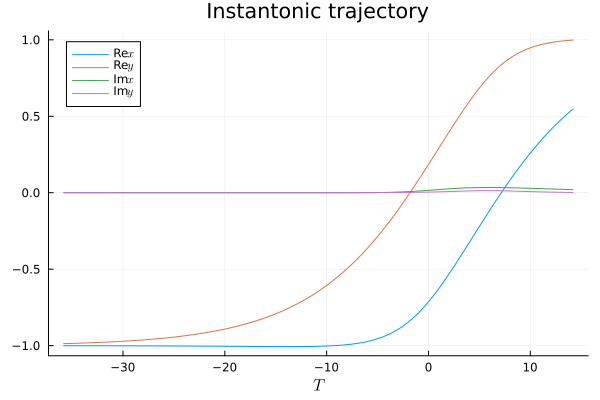

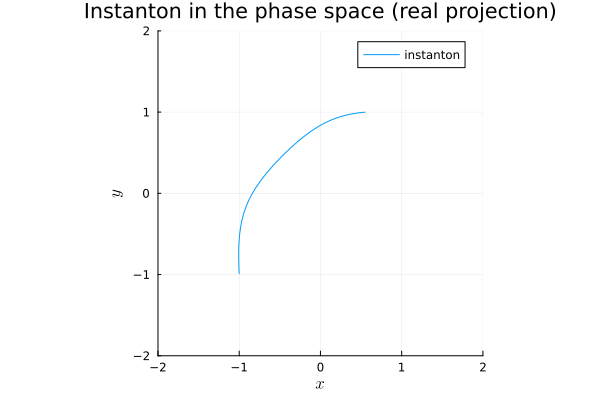


Total action = 40.45354253698828 - 0.7866389330858542im


(40.45354253698828 - 0.7866389330858542im, ComplexF64[-1.0006014270864911 - 1.6793230070118955e-5im -1.0006034025474178 - 1.6723993751078777e-5im … 0.5456120209973545 + 0.020142880876163952im 0.5470002402693305 + 0.02009159407891287im; -0.9868891966981084 + 1.6418369230931495e-5im -0.9868451743133797 + 1.6347341953363796e-5im … 0.9984204980061764 + 0.001746059983723477im 0.9985359904140789 + 0.0017270852258077696im])

In [ ]:
S_inst, sol = ST.instanton(system,coord, x_init = -1.0, direction_guess=[0.00, 0.05], T_backward=10.0, T_forward=40.0, dt=0.025)

# Charged capacitor field

An antiskyrmion is obtained by reflecting each spin along y. What about an in-plane field directed along y? Or a time-oscillating field?

A baby step towards understanding the latter would be to solve LLG numerically.

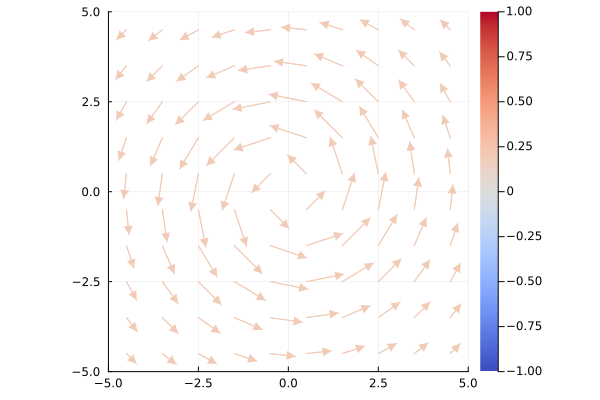

In [56]:
B = ST.rotational_B_field(lattice, B_max=3.0, radius=2.0, B_inf = 0.2)
ST.in_plane_quiver(B,lattice)

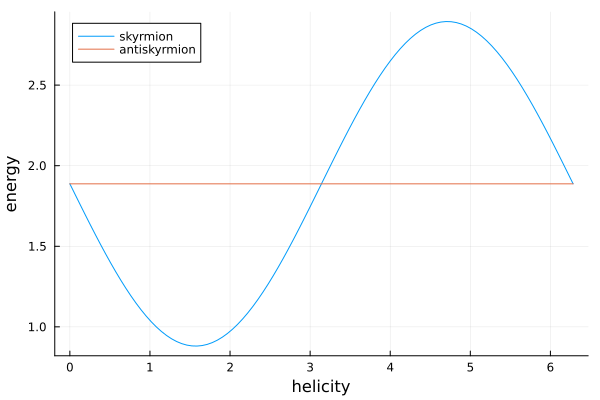

In [61]:
lattice = SquareLattice(40,40)
J1 = 1.0;	J2 = -0.3;	J3 = -0.2
K = 0.02

B = ST.rotational_B_field(lattice, B_max=0.1, radius=2.0, B_inf = 0.2)

params = HamiltonianParameters(J1,J2,J3,K,B)
boundary = PeriodicBoundary()
system = System(params,lattice,boundary)

helicity_list = LinRange(0,2pi,100)
Sk_energy_list = [ST.H(ST.skyrmion_ansatz(system, radius=2.0, relax_length=2.0, topological_charge=1.0, helicity=helicity),system) for helicity in helicity_list]
aSk_energy_list = [ST.H(ST.skyrmion_ansatz(system, radius=2.0, relax_length=2.0, topological_charge=-1.0, helicity=helicity),system) for helicity in helicity_list]
P = plot()
plot!(P,helicity_list, Sk_energy_list,label="skyrmion", xlabel="helicity", ylabel="energy")
plot!(P,helicity_list, aSk_energy_list,label="antiskyrmion", xlabel="helicity", ylabel="energy")
display(P)

Launching LLG relaxation for
SquareLattice(40, 40)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.3	J3 = -0.2
K = 0.02
Bz_avg = 0.2	B_uniform = true



Progress:  27%|███████████▏                             |  ETA: 0:00:38

could not find an improving step; stopped early


Progress: 100%|█████████████████████████████████████████| Time: 0:00:14


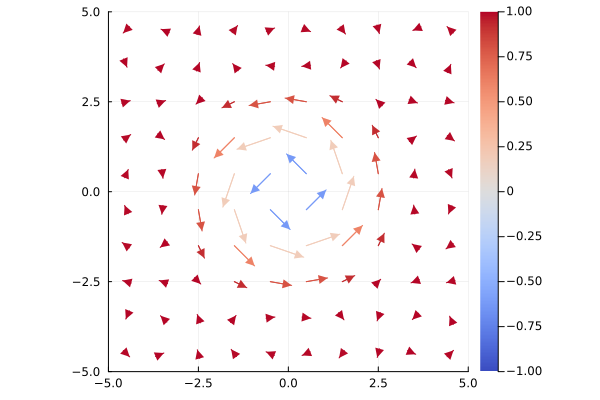

LambdaCoordinate{Matrix{ComplexF64}}(ComplexF64[-0.0021542003063961482 + 0.002158269274610285im -0.0008048820635096054 + 0.0050113676706018745im … -0.0008194341002385812 - 0.005008822445693857im -0.002160259724751923 - 0.002152264852773573im; -0.005010265114392781 + 0.0008179850673329304im -0.0017988229955545106 + 0.0018028817614043696im … -0.0018047210649348457 - 0.0017967842373368935im -0.005012714220887482 - 0.0008035735408882155im; … ; 0.005011635074252924 + 0.000804944506215478im 0.0018045771562591976 + 0.0018001177221336187im … 0.0017980511373123873 - 0.0018062150635725941im 0.005008915464177931 - 0.0008193583397985444im; 0.002157056487472671 + 0.0021528593741544327im 0.0008182199402779782 + 0.0050101938389109455im … 0.0008033956610979333 - 0.005012724421220139im 0.0021508972618143212 - 0.002158848089566686im])

In [77]:
n_Sk = ST.skyrmion(system, annealing=true, LLG_relax=true, show_result=false, N_steps=10000)
ST.in_plane_quiver(n_Sk,lattice)
coord = LambdaCoordinate(ST.w_project(n_Sk))

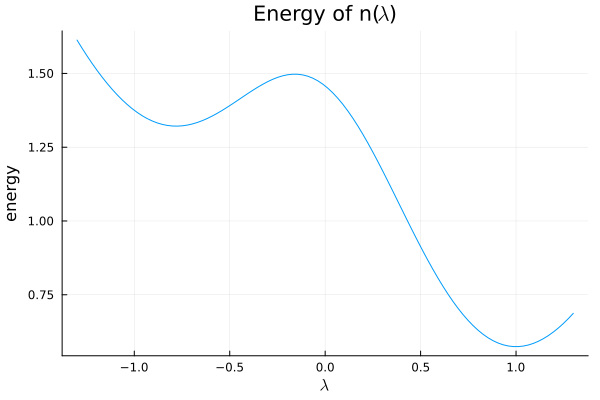

Imaginary part = 0.00028886249966782255
WARNING ----> imaginary part is nonzero !!!!! ---------> It gets neglected via a real projection


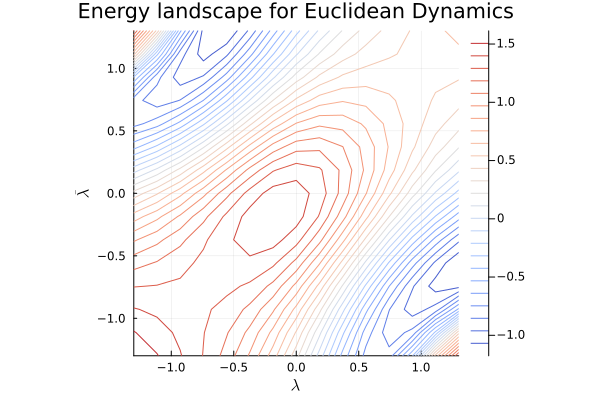

Imaginary part = 0.0023133278182298185
WARNING ----> imaginary part is nonzero !!!!! ---------> It gets neglected via a real projection


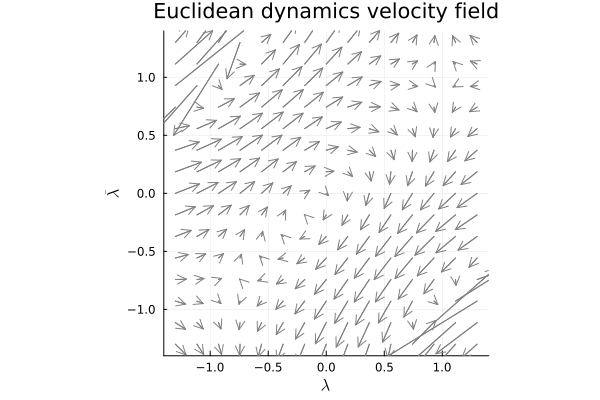

In [78]:
ST.describe_collective_coordinate(system,coord,xmin=-1.3, xmax=1.3)

In [ ]:
S_inst, sol = ST.instanton(system,coord, x_init = -1.0, direction_guess=[0.00, 0.05], T_backward=10.0, T_forward=20.0, dt=0.05)

The saddle point is at -0.7800904775639126

# Butterfly field

$$
\vec{B} = f(r) \cdot \Big( B_{\perp}(\cos 2\phi \; \vec{x} - \sin 2\phi \;\vec{y}) + \big( B_1 \cos (\phi + \phi_1) + B_2 \cos (2\phi+ \phi_2) + \big) \; \vec{z} \Big) + B_{\infty} \; \vec{z}
$$
where
$$
\qquad f(r) = \exp \Big( - \frac{(r-R_{Sk})^2}{R^2}\Big)
$$

$B_\perp, B_1, B_2, B_{\infty}, \phi_1, \phi_2, R_{Sk}, R$ are all parameters.

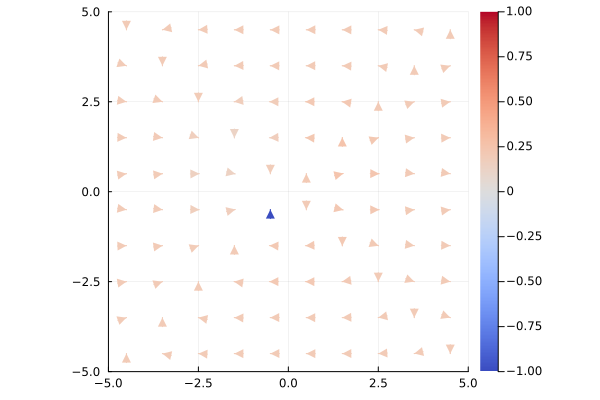

In [14]:
lattice = SquareLattice(40,40)
J1 = 1.0;	J2 = -0.3;	J3 = -0.2
K = 0.02

B = ST.butterfly_B(lattice, Bperp = 0.04, B1 = 0.05, B2 = -0.03, Binf=0.20, phi1 = 0.24, phi2 = 1.24, radius_Sk=2.0, radius_relax=1.0, B_defect=10.0)


params = HamiltonianParameters(J1,J2,J3,K,B)
boundary = PeriodicBoundary()
system = System(params,lattice,boundary)

ST.in_plane_quiver(B, lattice)

In [15]:
n_Sk = ST.skyrmion(system, annealing=true, LLG_relax=true, show_result=false, N_steps=50000)
println(ST.H(n_Sk, system))

Launching LLG relaxation for
SquareLattice(40, 40)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.3	J3 = -0.2
K = 0.02
Bz_avg = 0.194	B_uniform = false



Progress:  19%|███████▊                                 |  ETA: 0:03:45

could not find an improving step; stopped early


Progress: 100%|█████████████████████████████████████████| Time: 0:00:53


-19.07587146265655


In [16]:
n_aSk = ST.skyrmion(system, annealing=true, LLG_relax=true, show_result=false, N_steps=50000, topological_charge=-1)
println(ST.H(n_aSk, system))

Launching LLG relaxation for
SquareLattice(40, 40)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.3	J3 = -0.2
K = 0.02
Bz_avg = 0.194	B_uniform = false



Progress:  26%|██████████▊                              |  ETA: 0:03:30

could not find an improving step; stopped early


Progress: 100%|█████████████████████████████████████████| Time: 0:01:15


-19.03111506505593


In [20]:
function n_from_angles(theta,phi)
    return [sin(theta)*cos(phi), sin(theta)*sin(phi), cos(theta)]
end

n_from_angles (generic function with 1 method)

In [21]:
n_Sk[:,20,20] .= n_from_angles(pi-0.05,0.0)
n_aSk[:,20,20] .= n_from_angles(pi-0.05,0.0)

3-element view(::Array{Float64, 3}, :, 20, 20) with eltype Float64:
  0.049979169270678275
  0.0
 -0.9987502603949663

In [22]:
ST.H(n_Sk,system) - ST.H(n_aSk, system)

-0.043907355563078454

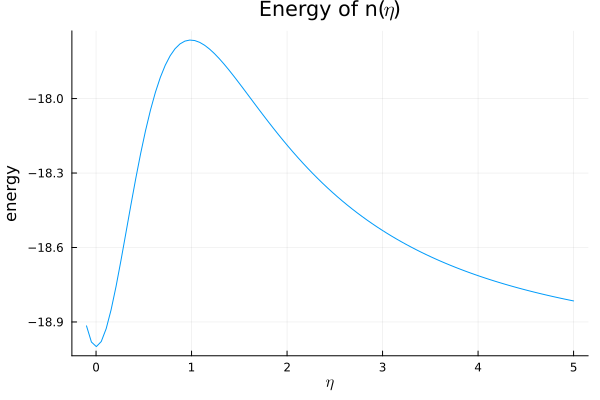

Imaginary part = 0.9076084999317076
WARNING ----> imaginary part is nonzero !!!!! ---------> It gets neglected via a real projection


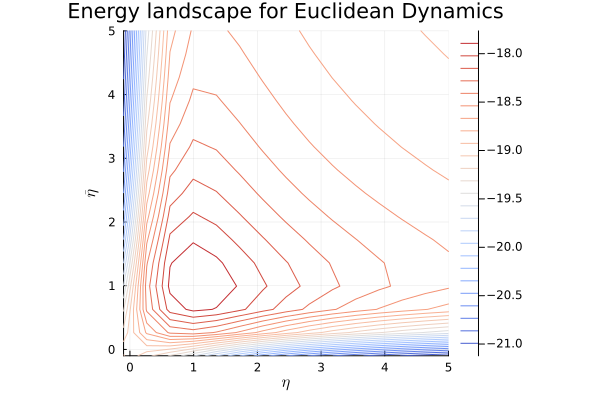

Imaginary part = 5.668540158207275
WARNING ----> imaginary part is nonzero !!!!! ---------> It gets neglected via a real projection


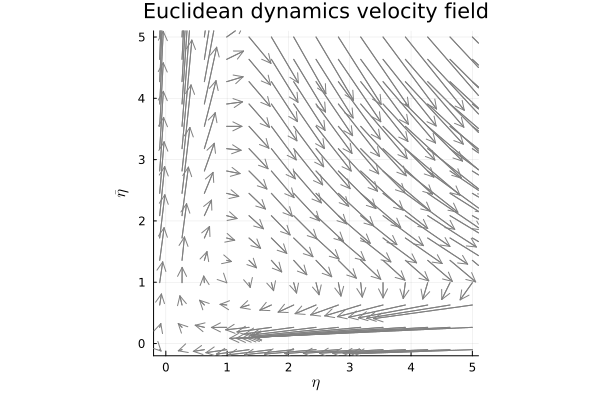

In [23]:
um, vm = ST.uv(n_Sk)
up, vp = ST.uv(n_aSk)

coord = EtaCoordinate(up,um,vp,vm)

ST.describe_collective_coordinate(system,coord,xmin=-0.1, xmax=5.0)

The saddle point is at 0.00043510578828361674 + 0.004761139244025436im
The instantonic trajectory passes through the point 
 x = -0.002843368641394998 + 0.0067193951637701905im
 y = 0.05030096039566784 + 0.004704627154151777im
sanity check : |H_inst-H0| = 2.9138072876216603e-12
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:09


-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


imaginary = 19.15582948992945


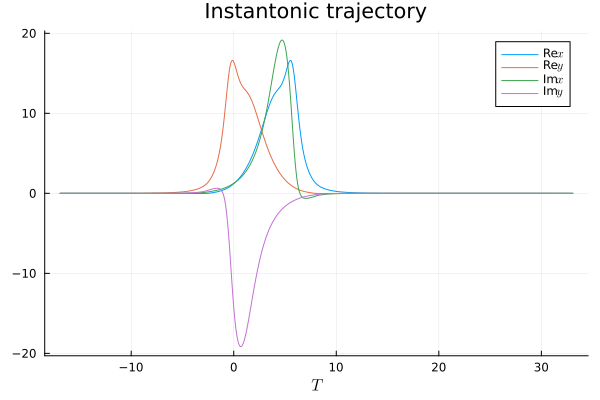

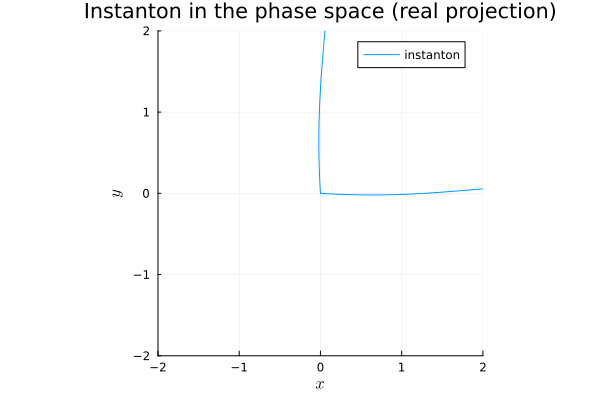


Total action = 22.737740937559654 - 0.2663968013517883im


(22.737740937559654 - 0.2663968013517883im, ComplexF64[0.0004286085180423386 + 0.004764325079059865im 0.00042850543649247837 + 0.004764373866435908im … 0.0008982107544575132 + 0.005914929038688016im 0.0009053680989781608 + 0.00593242332225606im; 0.0005283638764278149 - 0.004744064804231721im 0.0005298319199632957 - 0.004743794327949648im … 0.004403787494919499 - 0.021172491835173203im 0.004463441121139945 - 0.021432298314623874im])

In [27]:
S_inst, sol = ST.instanton(system,coord, x_init = 0.0, direction_guess=[0.00, 0.05], T_backward=10.0, T_forward=40.0, dt=0.025)

The saddle point is at 0.00043510578828361674 + 0.004761139244025436im
The instantonic trajectory passes through the point 
 x = -0.002843368641394998 + 0.0067193951637701905im
 y = 0.05030096039566784 + 0.004704627154151777im
sanity check : |H_inst-H0| = 2.9138072876216603e-12
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:19
Progress:   2%|▊                                        |  ETA: 0:00:05

-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:05


imaginary = 19.156904148408298


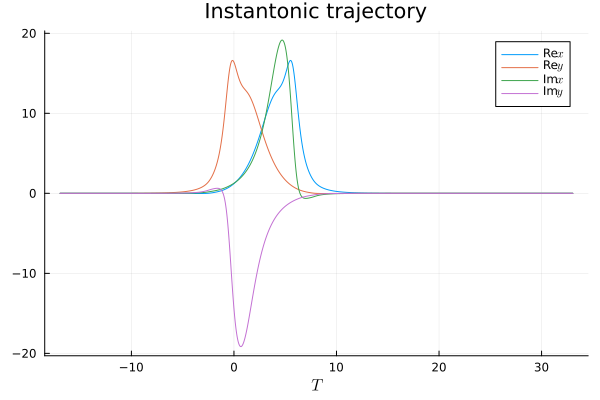

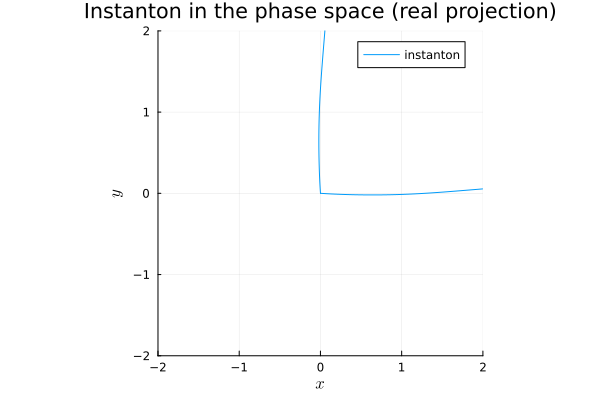


Total action = 22.70718862422426 - 0.06899219183144929im


(22.70718862422426 - 0.06899219183144929im, ComplexF64[0.00042860881182093564 + 0.004764325506778893im 0.00042855746952052314 + 0.004764349802155492im … 0.0004669168965655071 + 0.004835787037987537im 0.00046716398907798584 + 0.004836370681075556im; 0.000528363877009248 - 0.0047440648438777985im 0.0005290950315138961 - 0.004743930133770332im … 0.0006691535186481548 - 0.0057993293975726464im 0.0006709831699063949 - 0.005807472791571845im])

In [29]:
S_inst, sol = ST.instanton(system,coord, x_init = 0.0, direction_guess=[0.00, 0.05], T_backward=10.0, T_forward=40.0, dt=0.0125)